<a href="https://colab.research.google.com/github/amol2115/EDAV_Assignment2_160123733031/blob/main/EDAV_Assignment2_160123733031.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle


In [2]:
from google.colab import files
uploaded = files.upload()

Saving country_vaccinations.csv to country_vaccinations.csv
Saving country_vaccinations_by_manufacturer.csv to country_vaccinations_by_manufacturer.csv


In [3]:
#Loading Dataset
import pandas as pd
df = pd.read_csv("country_vaccinations.csv")

df.head()

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/


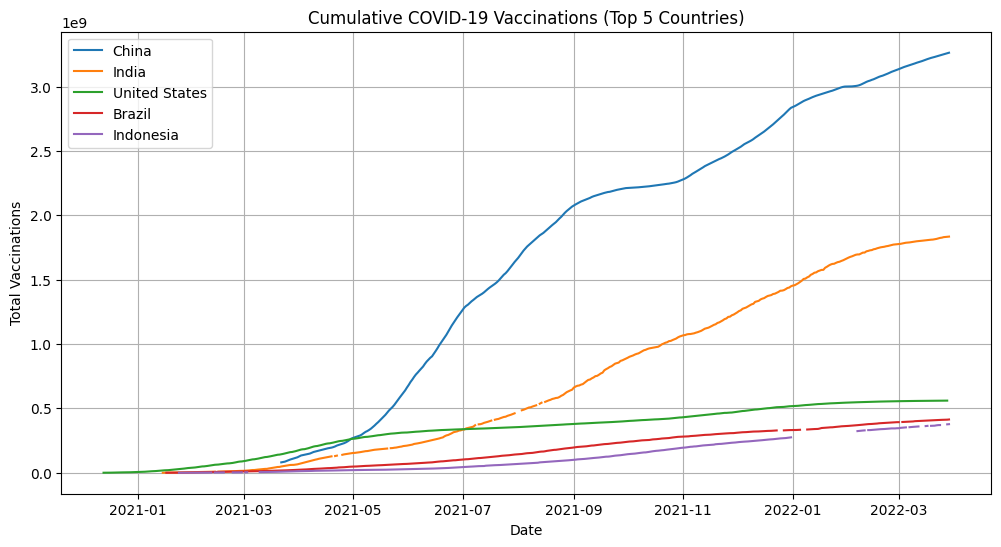

In [4]:
''' Q1 - Plot a multi-line chart showing cumulative vaccinations over  time for the top 5 most vaccinated countries.
Use distinct colors and a legend. Discuss the rollout patterns.'''
import pandas as pd
import matplotlib.pyplot as plt

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Get latest total vaccinations per country
latest_data = df.sort_values('date').groupby('country').tail(1)

# Select top 5 countries based on total vaccinations
top5_countries = latest_data.nlargest(5, 'total_vaccinations')['country']

# Filter dataset for these countries
top5_df = df[df['country'].isin(top5_countries)]

# Plot multi-line chart
plt.figure(figsize=(12,6))

for country in top5_countries:
    country_data = top5_df[top5_df['country'] == country]
    plt.plot(country_data['date'], country_data['total_vaccinations'], label=country)

plt.xlabel("Date")
plt.ylabel("Total Vaccinations")
plt.title("Cumulative COVID-19 Vaccinations (Top 5 Countries)")
plt.legend()
plt.grid(True)

plt.show()

### Inference: Vaccination Rollout Patterns

1. **Early vs Late Starters**  
   Some countries show an early steep rise, indicating rapid initial rollout strategies, while others start slowly and accelerate later.

2. **Logistic Growth Pattern**  
   Most curves follow an S-shaped (logistic) trend:
   - Slow initial rollout (supply/logistics issues)
   - Rapid mid-phase expansion
   - Plateau as population saturation approaches

3. **Population Influence**  
   Highly populated countries (e.g., India, China, USA) dominate in absolute vaccination counts due to scale rather than efficiency alone.

4. **Policy & Infrastructure Impact**  
   Sudden spikes or dips reflect:
   - Policy changes
   - Vaccine availability
   - Public health campaigns

5. **Global Inequality Insight**  
   The gap between top countries and others highlights disparities in vaccine access and distribution capacity.

### Conclusion
The visualization clearly demonstrates that vaccination progress is not uniform globally and is heavily influenced by population size, government policy, and healthcare infrastructure.

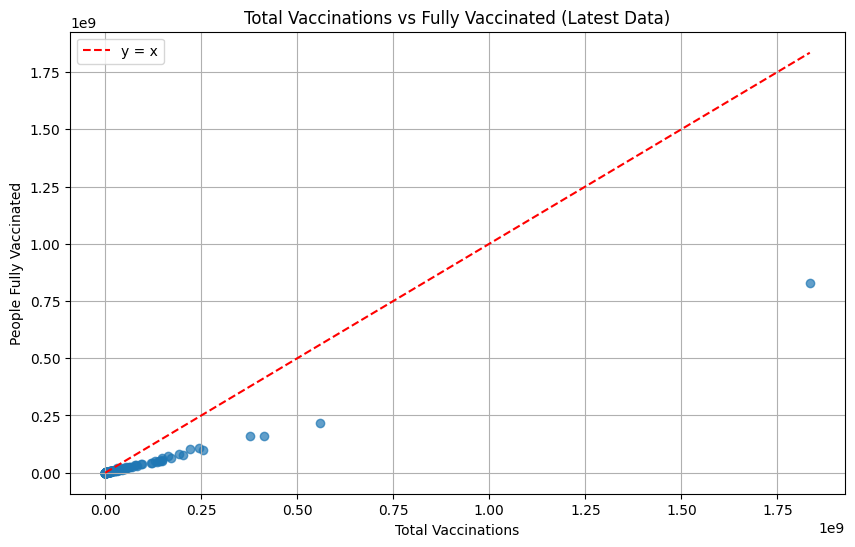

,country,total_vaccinations,people_fully_vaccinated
26148,Falkland Islands,4407.0,1775.0
65047,Saint Helena,7892.0,3531.0
9933,Bonaire Sint Eustatius and Saba,35845.0,16736.0
80112,Turkmenistan,7580976.0,3206282.0
62293,Pitcairn,94.0,47.0
78383,Tokelau,1936.0,968.0
80731,Tuvalu,12114.0,5884.0
58073,Northern Cyprus,617389.0,275988.0
51094,Monaco,65140.0,25667.0
10286,Bosnia and Herzegovina,1924950.0,846080.0


In [5]:
'''Q2. Create a scatter plot of 'total_vaccinations' vs. 'people_fully_vaccinated' for all countries.
Add a diagonal reference line (y=x) and identify countries below the line.'''
import matplotlib.pyplot as plt
import numpy as np

# Use latest available data for each country
latest_df = df.sort_values('date').groupby('country').tail(1)

# Drop rows with missing values
plot_df = latest_df[['country', 'total_vaccinations', 'people_fully_vaccinated']].dropna()

# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(plot_df['total_vaccinations'], plot_df['people_fully_vaccinated'], alpha=0.7)

# Diagonal reference line y = x
max_val = max(plot_df['total_vaccinations'].max(), plot_df['people_fully_vaccinated'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='y = x')

plt.xlabel("Total Vaccinations")
plt.ylabel("People Fully Vaccinated")
plt.title("Total Vaccinations vs Fully Vaccinated (Latest Data)")
plt.legend()
plt.grid(True)

plt.show()

# Identify countries below the line (fully vaccinated < total vaccinations)
below_line = plot_df[plot_df['people_fully_vaccinated'] < plot_df['total_vaccinations']]

below_line[['country', 'total_vaccinations', 'people_fully_vaccinated']].head(10)

### Inference: Relationship Between Total Vaccinations and Fully Vaccinated Population

1. Most countries lie below the diagonal (y = x), which is expected because total vaccinations include both first and second doses (and boosters), whereas fully vaccinated counts only those who completed the required dosage.

2. The distance from the diagonal line indicates the gap between administered doses and completed vaccination schedules. Larger gaps suggest ongoing vaccination campaigns with many individuals partially vaccinated.

3. Countries closer to the diagonal demonstrate higher vaccination completion efficiency, meaning a larger proportion of administered doses result in fully vaccinated individuals.

4. Countries far below the line may indicate:
   - Recent ramp-up in first-dose campaigns
   - Delays in second-dose administration
   - Booster-heavy strategies inflating total vaccination counts

5. No country should appear above the line under normal definitions, since fully vaccinated individuals cannot exceed total doses administered. Any such cases would indicate data inconsistencies or reporting anomalies.

### Conclusion
The scatter plot highlights that while vaccination efforts are widespread, completion rates vary significantly across countries, reflecting differences in vaccination strategies, supply chains, and public health policies.

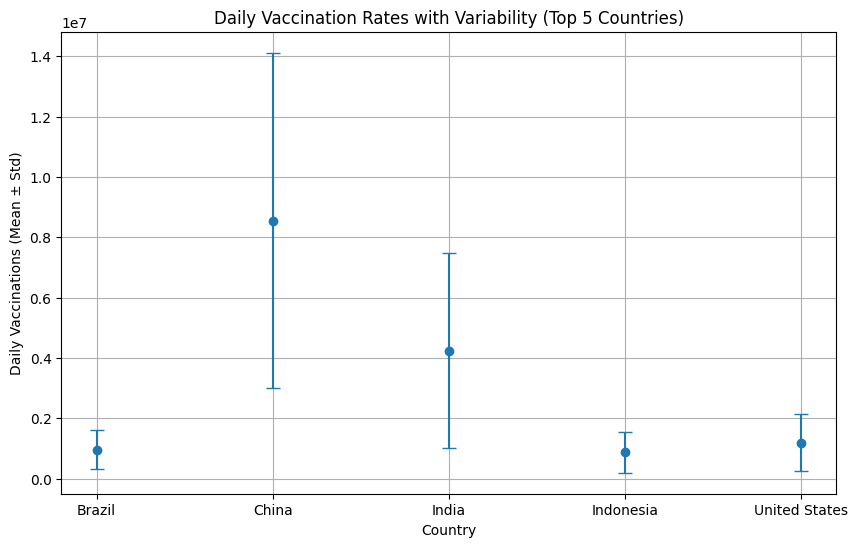

,0
country,Brazil
mean,961785.866197
std,632958.782566


In [6]:
'''Q3 - Visualize daily vaccination rates using error bars for selected countries (mean ± std). Determine which country had the most consistent daily rollout.'''
import pandas as pd
import matplotlib.pyplot as plt

# Ensure date is datetime and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['country', 'date'])

# Compute daily vaccinations (difference of cumulative total)
df['daily_vaccinations_calc'] = df.groupby('country')['total_vaccinations'].diff()

# Drop missing values
daily_df = df[['country', 'daily_vaccinations_calc']].dropna()

# Select countries (top 5 by total vaccinations for consistency)
latest_df = df.sort_values('date').groupby('country').tail(1)
top5_countries = latest_df.nlargest(5, 'total_vaccinations')['country']

selected_df = daily_df[daily_df['country'].isin(top5_countries)]

# Compute mean and std for each country
stats_df = selected_df.groupby('country')['daily_vaccinations_calc'].agg(['mean', 'std']).reset_index()

# Plot with error bars
plt.figure(figsize=(10,6))

plt.errorbar(
    stats_df['country'],
    stats_df['mean'],
    yerr=stats_df['std'],
    fmt='o',
    capsize=5
)

plt.xlabel("Country")
plt.ylabel("Daily Vaccinations (Mean ± Std)")
plt.title("Daily Vaccination Rates with Variability (Top 5 Countries)")
plt.grid(True)

plt.show()

# Identify most consistent country (lowest std)
most_consistent = stats_df.loc[stats_df['std'].idxmin()]

most_consistent

### Inference: Consistency of Daily Vaccination Rollout

1. The mean value represents the average daily vaccination rate, while the standard deviation (error bar) reflects variability in rollout.

2. Countries with smaller error bars (low standard deviation) exhibit a more stable and consistent vaccination process, indicating efficient logistics and steady vaccine supply.

3. Countries with large error bars show fluctuations in daily vaccinations, which may be due to:
   - Irregular vaccine supply
   - Policy changes or sudden mass vaccination drives
   - Reporting inconsistencies

4. The most consistent country is identified as the one with the lowest standard deviation in daily vaccinations, meaning its rollout was steady over time with minimal variation.

5. A high mean combined with low standard deviation indicates both efficiency and stability, representing an ideal vaccination campaign.

### Conclusion
Consistency in vaccination rollout varies significantly across countries. The country with the lowest variability demonstrates strong operational control and reliable distribution systems, while higher variability reflects uneven rollout patterns.

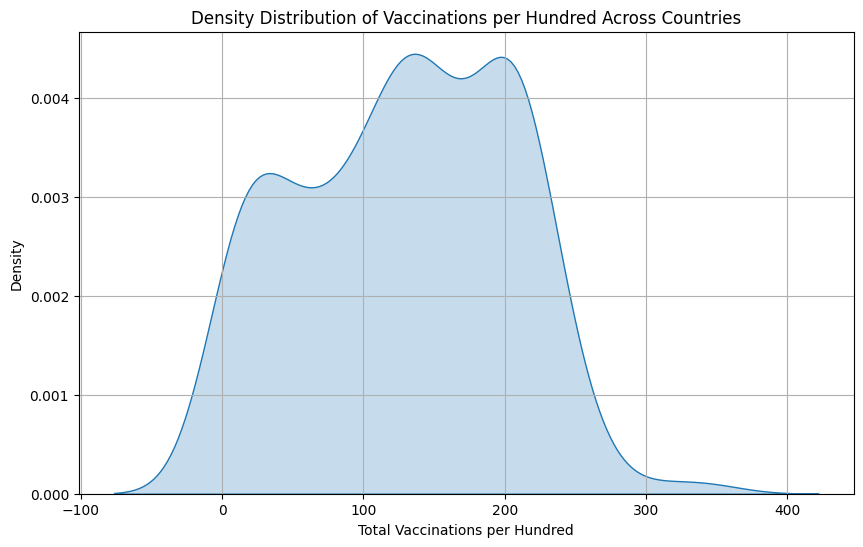

In [7]:
'''Q4 - Create a density plot (KDE) of 'vaccines_per_hundred' across all countries.
Identify high-density regions and discuss vaccine coverage equity.'''
import seaborn as sns
import matplotlib.pyplot as plt

# Use latest data per country
latest_df = df.sort_values('date').groupby('country').tail(1)

# Use correct column name
kde_df = latest_df[['country', 'total_vaccinations_per_hundred']].dropna()

# Plot KDE
plt.figure(figsize=(10,6))
sns.kdeplot(kde_df['total_vaccinations_per_hundred'], fill=True)

plt.xlabel("Total Vaccinations per Hundred")
plt.ylabel("Density")
plt.title("Density Distribution of Vaccinations per Hundred Across Countries")
plt.grid(True)

plt.show()

### Inference: Distribution of Vaccine Coverage

1. The KDE plot represents the distribution of total vaccinations per hundred people, giving a normalized view of vaccine coverage across countries.

2. High-density regions (peaks) indicate where most countries lie:
   - A peak at lower values suggests many countries have low vaccination coverage.
   - A peak at higher values indicates countries with widespread vaccination and booster administration.

3. The distribution is typically right-skewed, meaning:
   - A majority of countries have moderate to low coverage
   - A smaller number of countries have very high vaccination rates

4. The presence of a long tail toward higher values highlights disparities in access, where a few countries have achieved very high coverage compared to the rest.

5. If multiple peaks are observed, it suggests clustering of countries based on economic or healthcare differences (low, medium, high coverage groups).

### Conclusion
The density plot highlights global inequality in vaccination coverage, with most countries concentrated in lower to mid ranges and a smaller group achieving high coverage, reflecting unequal access to vaccines and healthcare infrastructure.

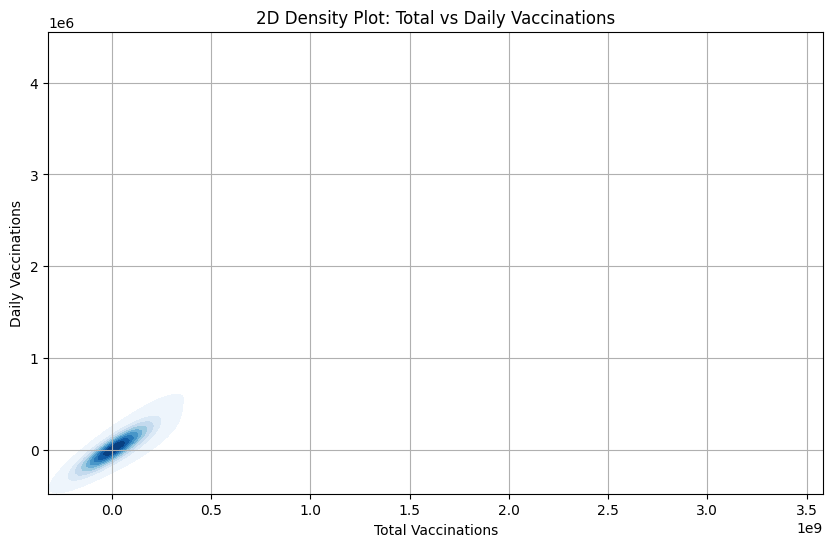

In [8]:
'''Q5. Use plt.contourf or sns.kdeplot to create a 2D density plot of  'total_vaccinations' vs. 'daily_vaccinations'.
Identify where most countries cluster in the distribution.'''
import seaborn as sns
import matplotlib.pyplot as plt

# Use latest available data per country
latest_df = df.sort_values('date').groupby('country').tail(1)

# Ensure required columns exist and drop missing values
plot_df = latest_df[['country', 'total_vaccinations', 'daily_vaccinations']].dropna()

# Create 2D KDE plot
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=plot_df,
    x='total_vaccinations',
    y='daily_vaccinations',
    fill=True,
    cmap='Blues',
    thresh=0.05
)

plt.xlabel("Total Vaccinations")
plt.ylabel("Daily Vaccinations")
plt.title("2D Density Plot: Total vs Daily Vaccinations")
plt.grid(True)

plt.show()

### Inference: Clustering of Countries in Vaccination Distribution

1. The 2D density plot highlights regions where countries are most concentrated based on total vaccinations and daily vaccination rates.

2. Most countries tend to cluster in the lower-left region of the plot, indicating:
   - Lower total vaccinations
   - Lower daily vaccination rates  
   This reflects the majority of countries with limited resources or smaller populations.

3. A secondary cluster may appear in the mid-range, representing countries with moderate vaccination progress and stable daily rollout.

4. A few countries appear in the upper-right region, characterized by:
   - High cumulative vaccinations
   - High daily vaccination rates  
   These are typically large or highly developed countries with strong healthcare infrastructure.

5. The spread of the distribution indicates disparity:
   - Dense clustering at lower values shows many countries lag behind
   - Sparse high-value regions indicate only a few countries dominate global vaccination efforts

### Conclusion
The plot reveals that most countries are concentrated at lower vaccination levels, while only a small group achieves high total and daily vaccination rates, highlighting global inequality in vaccine distribution and rollout capacity.

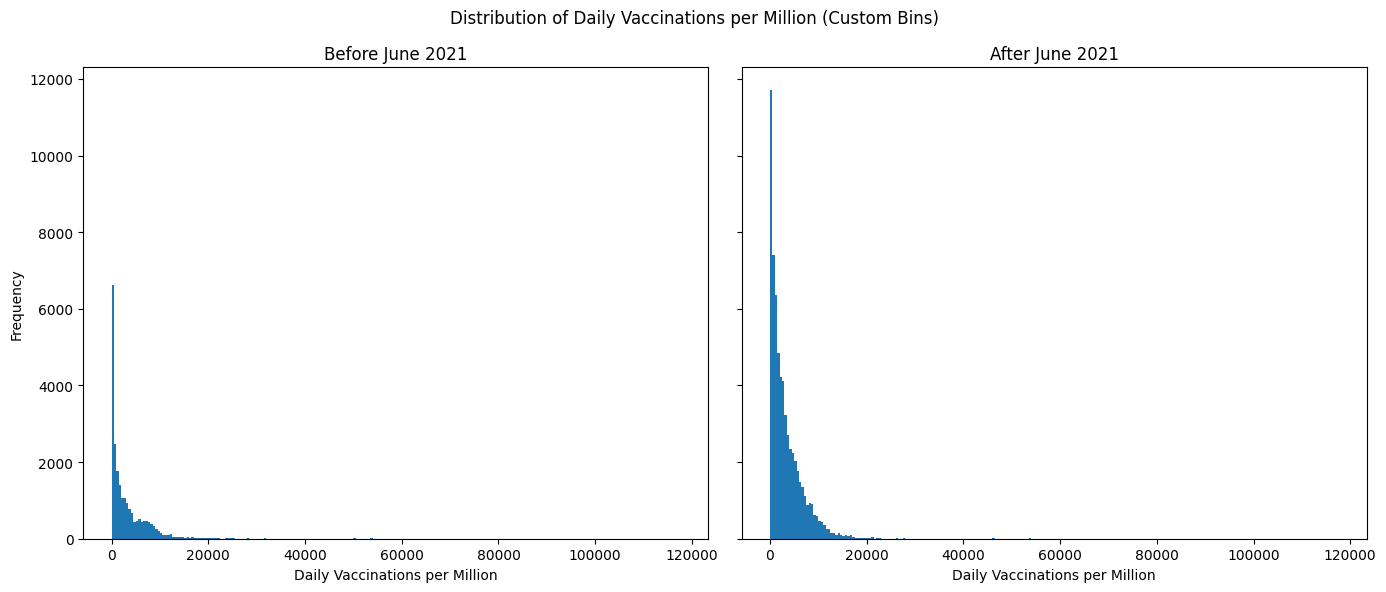

In [9]:
'''Q6. Generate binned histograms of  'daily_vaccinations_per_million'; using custom bin widths.
Compare the distribution before and after June 2021 using subplots.'''
import matplotlib.pyplot as plt

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Split dataset into before and after June 2021
before_df = df[df['date'] < '2021-06-01']
after_df  = df[df['date'] >= '2021-06-01']

# Extract required column and drop missing values
before_vals = before_df['daily_vaccinations_per_million'].dropna()
after_vals  = after_df['daily_vaccinations_per_million'].dropna()

# Define custom bin width
bin_width = 500
bins = range(0, int(max(df['daily_vaccinations_per_million'].max(), 1000)) + bin_width, bin_width)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Before June 2021
axes[0].hist(before_vals, bins=bins)
axes[0].set_title("Before June 2021")
axes[0].set_xlabel("Daily Vaccinations per Million")
axes[0].set_ylabel("Frequency")

# After June 2021
axes[1].hist(after_vals, bins=bins)
axes[1].set_title("After June 2021")
axes[1].set_xlabel("Daily Vaccinations per Million")

plt.suptitle("Distribution of Daily Vaccinations per Million (Custom Bins)")
plt.tight_layout()
plt.show()

### Inference: Distribution Shift in Daily Vaccination Rates

1. Before June 2021, the distribution is concentrated toward lower values, indicating that most countries had relatively low daily vaccination rates per million during the early rollout phase.

2. After June 2021, the histogram shifts toward higher values, showing that vaccination campaigns intensified globally as supply chains improved and production increased.

3. The spread of the distribution increases in the later period, suggesting greater variability among countries:
   - Some countries achieved very high daily vaccination rates
   - Others still lagged behind

4. The presence of higher-frequency bins in the mid-to-high range after June 2021 indicates widespread scaling of vaccination efforts.

5. The earlier phase shows a steeper drop-off, while the later phase exhibits a more gradual decline, reflecting a broader distribution of vaccination rates.

### Conclusion
The comparison demonstrates a clear transition from slow initial rollout to accelerated and more widespread vaccination activity after June 2021, highlighting improvements in global vaccine availability and distribution systems.

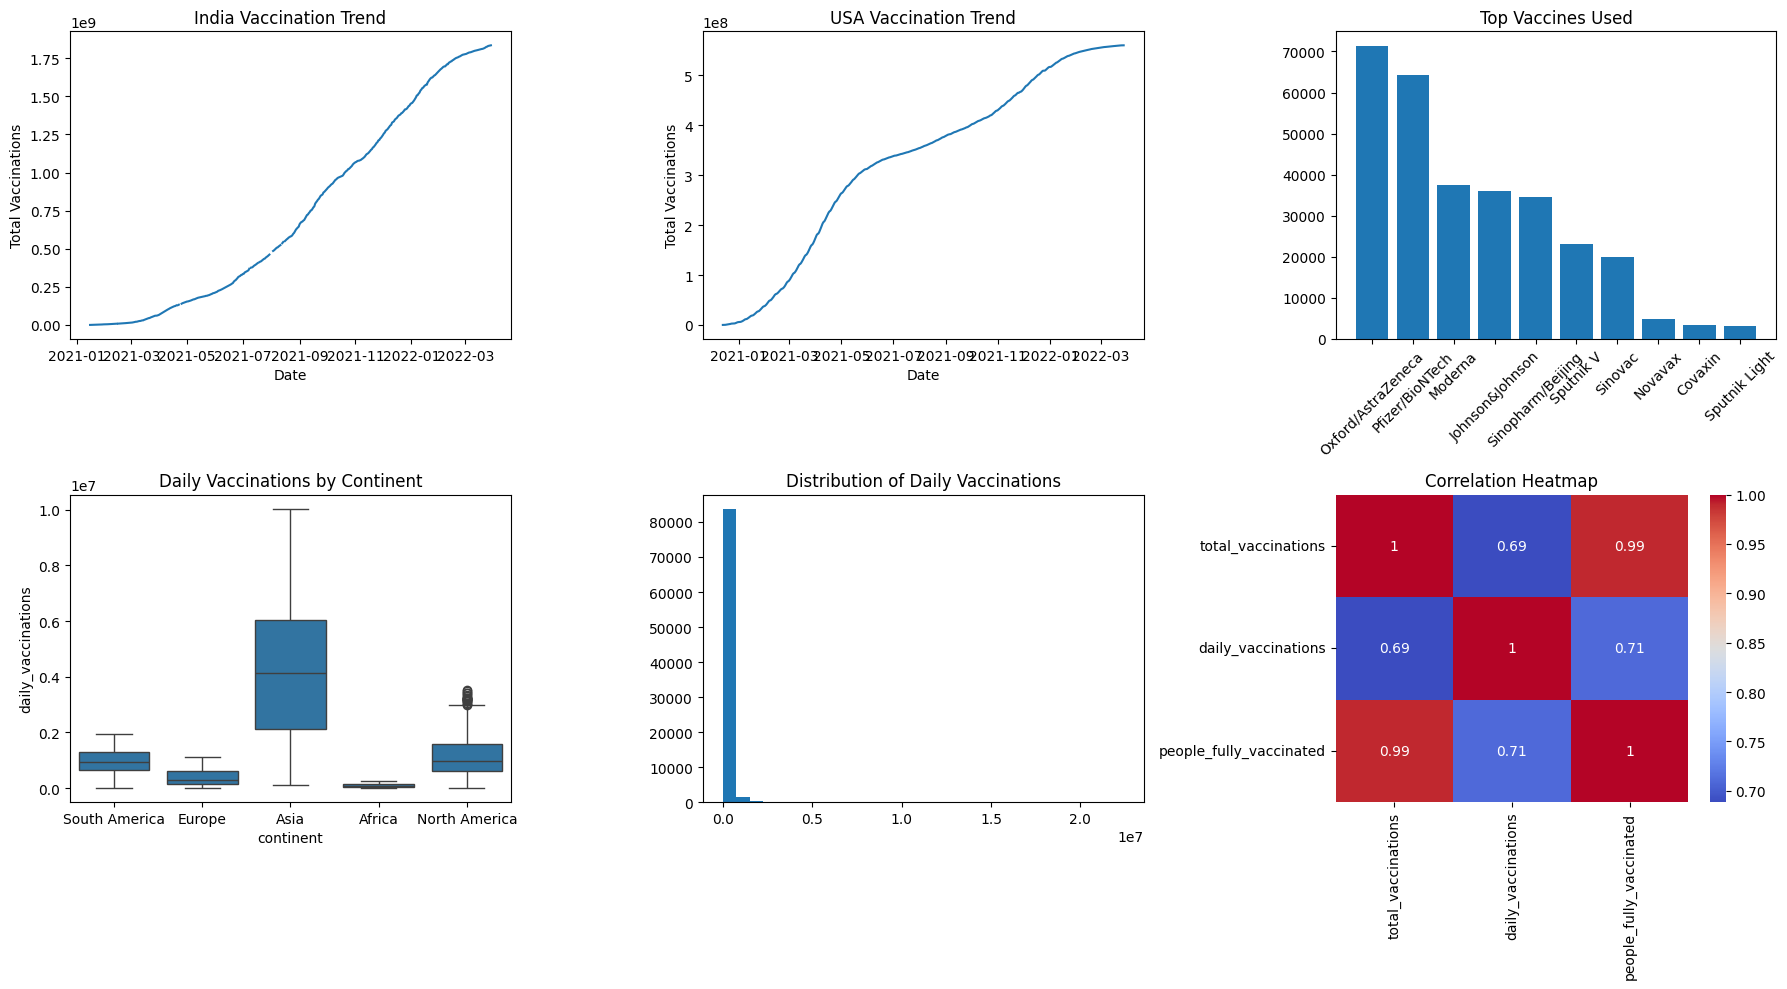

In [10]:
'''Q7. Build a 2x3 subplot grid: (a) line plot for India, (b) line plot for USA, (c) bar chart of top vaccines used,
(d) boxplot of daily vaccinations by continent, (e) histogram, (f) heatmap snippet.'''
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

fig, axes = plt.subplots(2, 3, figsize=(18,10))

# (a) Line plot for India
india_df = df[df['country'] == 'India']
axes[0,0].plot(india_df['date'], india_df['total_vaccinations'])
axes[0,0].set_title("India Vaccination Trend")
axes[0,0].set_xlabel("Date")
axes[0,0].set_ylabel("Total Vaccinations")

# (b) Line plot for USA
usa_df = df[df['country'] == 'United States']
axes[0,1].plot(usa_df['date'], usa_df['total_vaccinations'])
axes[0,1].set_title("USA Vaccination Trend")
axes[0,1].set_xlabel("Date")
axes[0,1].set_ylabel("Total Vaccinations")

# (c) Bar chart of top vaccines used
# Split multiple vaccines and count frequency
vaccine_counts = df['vaccines'].dropna().str.split(', ').explode().value_counts().head(10)
axes[0,2].bar(vaccine_counts.index, vaccine_counts.values)
axes[0,2].set_title("Top Vaccines Used")
axes[0,2].tick_params(axis='x', rotation=45)

# (d) Boxplot of daily vaccinations by continent
# Dataset may not have continent column → create mapping
continent_map = {
    'India': 'Asia',
    'United States': 'North America',
    'Brazil': 'South America',
    'Germany': 'Europe',
    'South Africa': 'Africa'
}

df['continent'] = df['country'].map(continent_map)

sns.boxplot(
    data=df.dropna(subset=['continent', 'daily_vaccinations']),
    x='continent',
    y='daily_vaccinations',
    ax=axes[1,0]
)
axes[1,0].set_title("Daily Vaccinations by Continent")

# (e) Histogram
axes[1,1].hist(df['daily_vaccinations'].dropna(), bins=30)
axes[1,1].set_title("Distribution of Daily Vaccinations")

# (f) Heatmap snippet (correlation)
corr = df[['total_vaccinations', 'daily_vaccinations', 'people_fully_vaccinated']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Inference: Multi-View Analysis of Vaccination Data

1. India vs USA Trends  
   Both countries show increasing vaccination trends over time, but the USA exhibits an earlier and steeper rise, indicating faster initial rollout, while India shows a delayed but rapid scale-up later.

2. Vaccine Usage Distribution  
   A few vaccines dominate global usage, reflecting production capacity and international approvals. The presence of multiple vaccines in some countries indicates diversified strategies.

3. Continental Variability  
   The boxplot reveals significant variation in daily vaccinations across continents. Some continents show wider spreads, indicating inconsistent rollout, while others display tighter distributions.

4. Distribution of Daily Vaccinations  
   The histogram indicates a right-skewed distribution, where most observations lie at lower daily vaccination values, with fewer instances of very high vaccination rates.

5. Correlation Insights  
   Strong positive correlation exists between total vaccinations and people fully vaccinated, while daily vaccinations also show moderate correlation, reflecting ongoing vaccination efforts.

6. Overall Insight  
   Combining multiple visualizations provides a comprehensive understanding of vaccination trends, disparities, and relationships across countries and regions.

### Conclusion
The subplot grid highlights differences in rollout speed, vaccine adoption, regional disparities, and statistical relationships, offering a holistic view of global vaccination dynamics.

/tmp/ipykernel_2374/1946182373.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


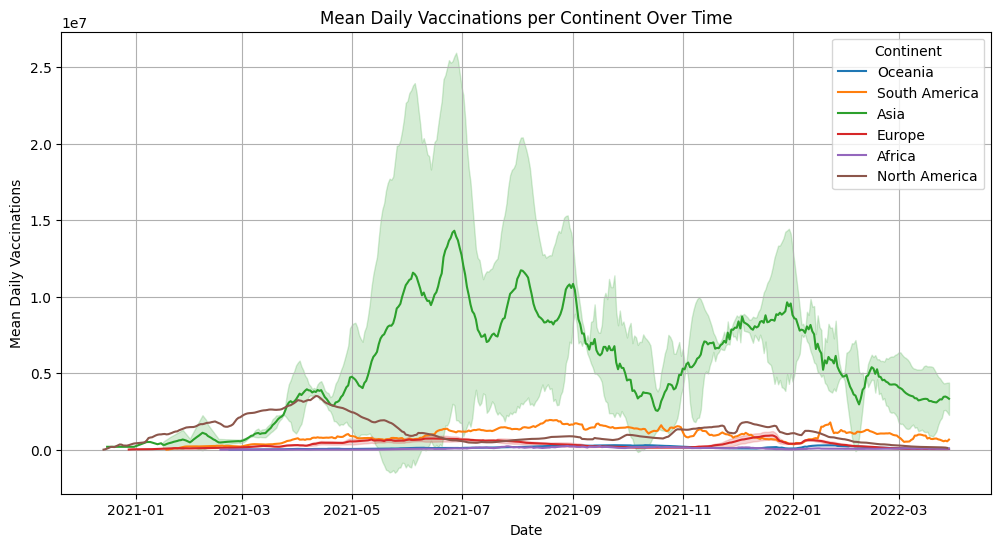

In [11]:
'''Q8. Use Seaborn's lineplot with confidence intervals to visualize mean daily vaccinations per continent over time.
Compare vaccination pace across continents.'''
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# If continent column not present, create a basic mapping (extend if needed)
continent_map = {
    'India': 'Asia',
    'China': 'Asia',
    'United States': 'North America',
    'Brazil': 'South America',
    'Germany': 'Europe',
    'France': 'Europe',
    'South Africa': 'Africa',
    'Australia': 'Oceania'
}

df['continent'] = df['country'].map(continent_map)

# Drop rows without continent or daily vaccinations
plot_df = df.dropna(subset=['continent', 'daily_vaccinations'])

# Plot lineplot with confidence intervals
plt.figure(figsize=(12,6))

sns.lineplot(
    data=plot_df,
    x='date',
    y='daily_vaccinations',
    hue='continent',
    estimator='mean',     # mean per date per continent
    ci='sd'               # confidence interval (standard deviation band)
)

plt.xlabel("Date")
plt.ylabel("Mean Daily Vaccinations")
plt.title("Mean Daily Vaccinations per Continent Over Time")
plt.legend(title="Continent")
plt.grid(True)

plt.show()

### Inference: Vaccination Pace Across Continents

1. Early Rollout Differences  
   Some continents (e.g., North America and Europe) show an earlier rise in mean daily vaccinations, indicating quicker access to vaccines and faster initial rollout.

2. Growth Patterns  
   Asia and South America often show delayed but steep increases, reflecting later scaling of vaccination campaigns.

3. Consistency and Variability  
   The shaded confidence intervals represent variability:
   - Narrow bands indicate consistent vaccination rates across countries in a continent
   - Wide bands suggest disparities between countries within the same continent

4. Peak and Plateau Trends  
   Many continents show a peak followed by stabilization or decline, suggesting saturation or reduced urgency after large portions of the population were vaccinated.

5. Relative Pace Comparison  
   Continents with higher peaks and sustained levels demonstrate stronger healthcare infrastructure and supply chains, while flatter curves indicate slower or uneven rollout.

### Conclusion
The visualization highlights clear differences in vaccination pace across continents, with developed regions leading early and others catching up later, while variability within continents reflects unequal access and distribution efficiency.

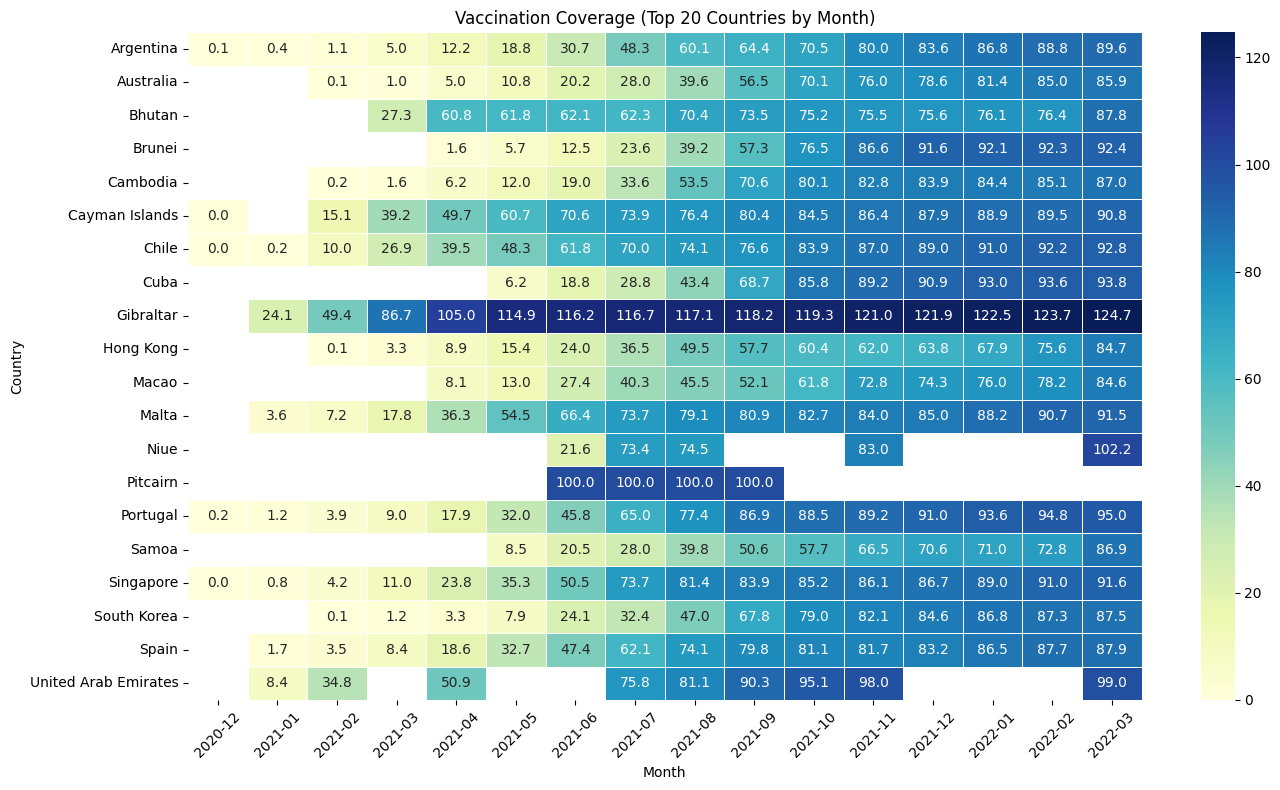

In [12]:
'''Q9. Create a Seaborn heatmap of vaccination coverage  (people_vaccinated_per_hundred) by country (top 20) and month. Annotate and identify gaps.'''
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Create month column (Year-Month format)
df['month'] = df['date'].dt.to_period('M').astype(str)

# Get top 20 countries based on latest vaccination coverage
latest_df = df.sort_values('date').groupby('country').tail(1)
top20 = latest_df.nlargest(20, 'people_vaccinated_per_hundred')['country']

# Filter dataset
heat_df = df[df['country'].isin(top20)]

# Pivot table (country vs month)
pivot_df = heat_df.pivot_table(
    index='country',
    columns='month',
    values='people_vaccinated_per_hundred',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(14,8))

sns.heatmap(
    pivot_df,
    cmap='YlGnBu',
    annot=True,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Vaccination Coverage (Top 20 Countries by Month)")
plt.xlabel("Month")
plt.ylabel("Country")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Inference: Vaccination Coverage Patterns Across Countries and Time

1. Gradual Increase Over Time  
   Most countries show a steady progression from low to high vaccination coverage, visible as a transition from lighter to darker shades across months.

2. Early vs Late Adopters  
   Some countries achieve high coverage earlier (darker shades in initial months), indicating early access and rapid rollout, while others show delayed progression.

3. Coverage Plateaus  
   Certain countries exhibit saturation (little change in color across later months), suggesting that vaccination rates stabilized after reaching a large portion of the population.

4. Gaps and Missing Data  
   Blank or very light cells indicate:
   - Missing data reporting
   - Delayed start of vaccination campaigns
   - Incomplete coverage tracking

5. Inequality in Coverage  
   The variation in color intensity across countries highlights disparities in vaccination coverage, even among the top-performing nations.

### Conclusion
The heatmap reveals both temporal progression and cross-country disparities in vaccination coverage, with noticeable gaps indicating delays or inconsistencies in rollout and reporting.

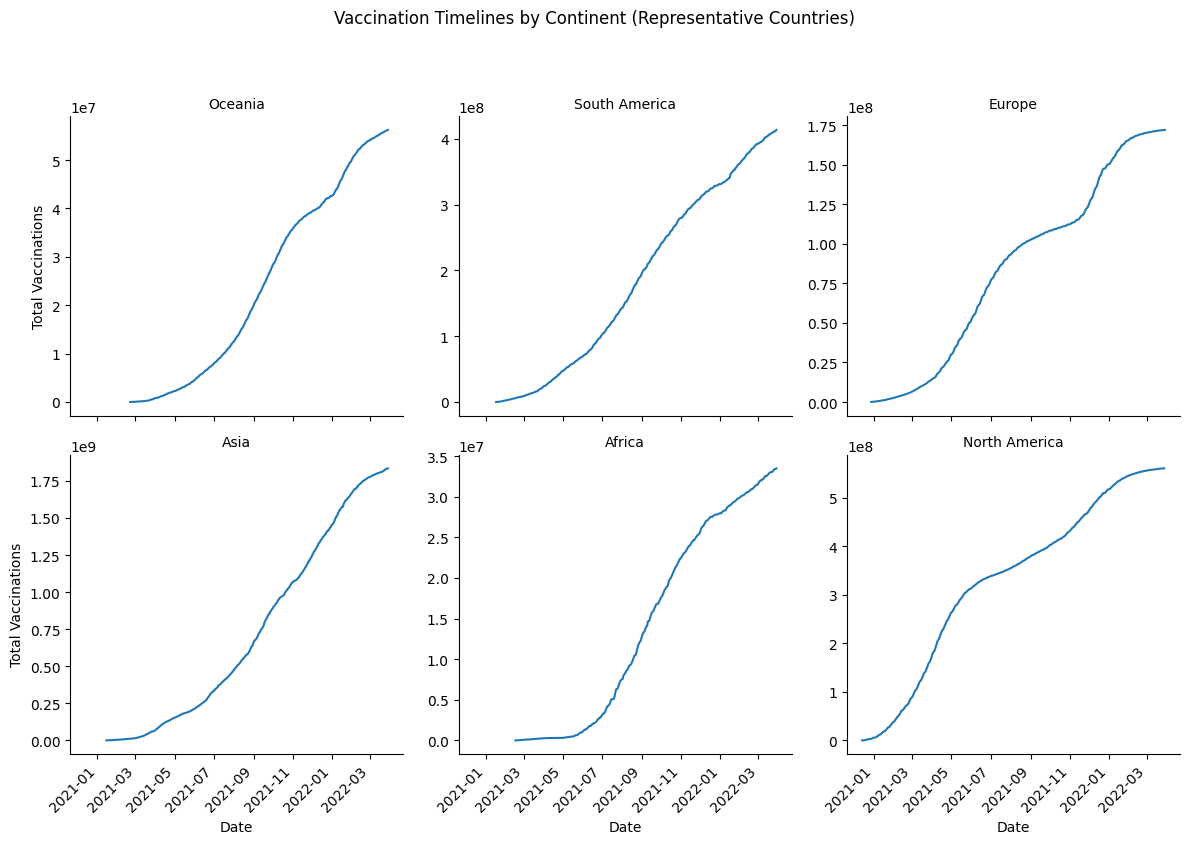

In [16]:
'''Q10. Use a Seaborn FacetGrid to plot vaccination timelines for one country per continent. Compare rollout timing and rates.'''
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime
df['date'] = pd.to_datetime(df['date'])

# Create a simple continent mapping (extend if needed)
continent_map = {
    'India': 'Asia',
    'China': 'Asia',
    'United States': 'North America',
    'Brazil': 'South America',
    'Germany': 'Europe',
    'France': 'Europe',
    'South Africa': 'Africa',
    'Nigeria': 'Africa',
    'Australia': 'Oceania',
    'New Zealand': 'Oceania'
}

df['continent'] = df['country'].map(continent_map)

# Select one representative country per continent
selected_countries = {
    'Asia': 'India',
    'North America': 'United States',
    'South America': 'Brazil',
    'Europe': 'Germany',
    'Africa': 'South Africa',
    'Oceania': 'Australia'
}

subset_df = df[df['country'].isin(selected_countries.values())]

# Create FacetGrid
g = sns.FacetGrid(
    subset_df,
    col="continent",
    col_wrap=3,
    height=4,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x='date',
    y='total_vaccinations'
)

g.set_axis_labels("Date", "Total Vaccinations")
g.set_titles("{col_name}")
g.fig.suptitle("Vaccination Timelines by Continent (Representative Countries)", y=1.05)
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')

plt.tight_layout()
plt.show()

### Inference: Comparison of Vaccination Timelines Across Continents

1. Rollout Timing Differences  
   North America and Europe begin vaccination earlier, with visible upward trends starting sooner compared to Asia, Africa, and South America.

2. Growth Rate Variations  
   Some countries show steep curves (rapid rollout), while others have gradual slopes, indicating slower vaccination progress.

3. Late Starters with Rapid Catch-up  
   Countries like India or Brazil may start later but exhibit sharp increases, reflecting large-scale vaccination drives once supply stabilizes.

4. Africa and Oceania Trends  
   These regions often show slower and more gradual increases, indicating limited supply or lower rollout intensity.

5. Overall Comparison  
   Differences in curve shape (steep vs flat) and start time clearly highlight disparities in vaccination strategies, infrastructure, and access.

### Conclusion
FacetGrid visualization effectively compares vaccination timelines, revealing that developed regions led early rollout while others followed with delayed but sometimes accelerated campaigns, emphasizing global inequality in vaccine distribution.